In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [31]:
train = pd.read_csv("train.csv")
features = pd.read_csv("features.csv")
stores = pd.read_csv("stores.csv")


In [8]:
print(train.head())
print(train.info())
print(train.describe())

print(features.head())
print(stores.head())


   Store  Dept        Date  Weekly_Sales  IsHoliday
0      1     1  2010-02-05      24924.50      False
1      1     1  2010-02-12      46039.49       True
2      1     1  2010-02-19      41595.55      False
3      1     1  2010-02-26      19403.54      False
4      1     1  2010-03-05      21827.90      False
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB
None
               Store           Dept   Weekly_Sales
count  421570.000000  421570.000000  421570.000000
mean       22.200546      44.260317   15981.258123
std        12.785297      30.492054   22

In [11]:
train = pd.read_csv("train.csv")

In [13]:
df = pd.read_csv("train.csv")

In [14]:
# 3. Basic info
print("Dataset Overview:\n")
print(df.head())
print("\nDataset Info:\n")
print(df.info())
print("\nMissing Values:\n")
print(df.isnull().sum())

Dataset Overview:

   Store  Dept        Date  Weekly_Sales  IsHoliday
0      1     1  2010-02-05      24924.50      False
1      1     1  2010-02-12      46039.49       True
2      1     1  2010-02-19      41595.55      False
3      1     1  2010-02-26      19403.54      False
4      1     1  2010-03-05      21827.90      False

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB
None

Missing Values:

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64


In [15]:
# 4. Convert 'Date' to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# 5. Create new time-related features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week

In [16]:
# 6. Describe sales
print("\nWeekly Sales Summary:\n")
print(df['Weekly_Sales'].describe())


Weekly Sales Summary:

count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64


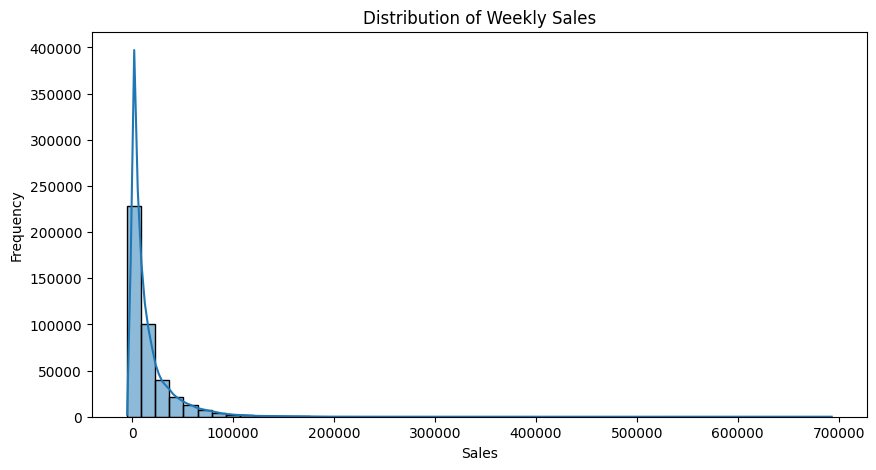

In [17]:
# 7. Sales distribution plot
plt.figure(figsize=(10,5))
sns.histplot(df['Weekly_Sales'], bins=50, kde=True)
plt.title("Distribution of Weekly Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

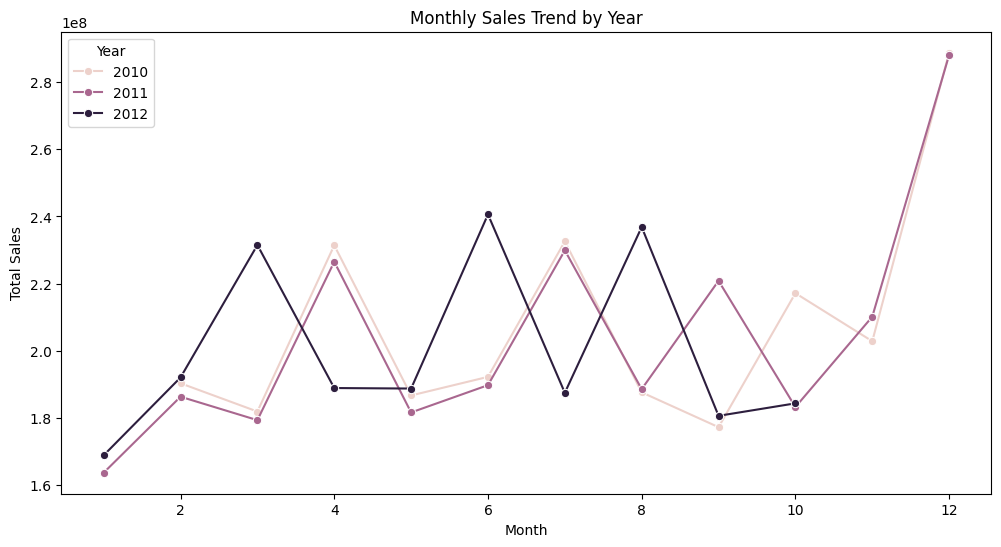

In [18]:
# 8. Time-series trend by year & month
monthly_sales = df.groupby(['Year', 'Month'])['Weekly_Sales'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_sales, x='Month', y='Weekly_Sales', hue='Year', marker="o")
plt.title("Monthly Sales Trend by Year")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

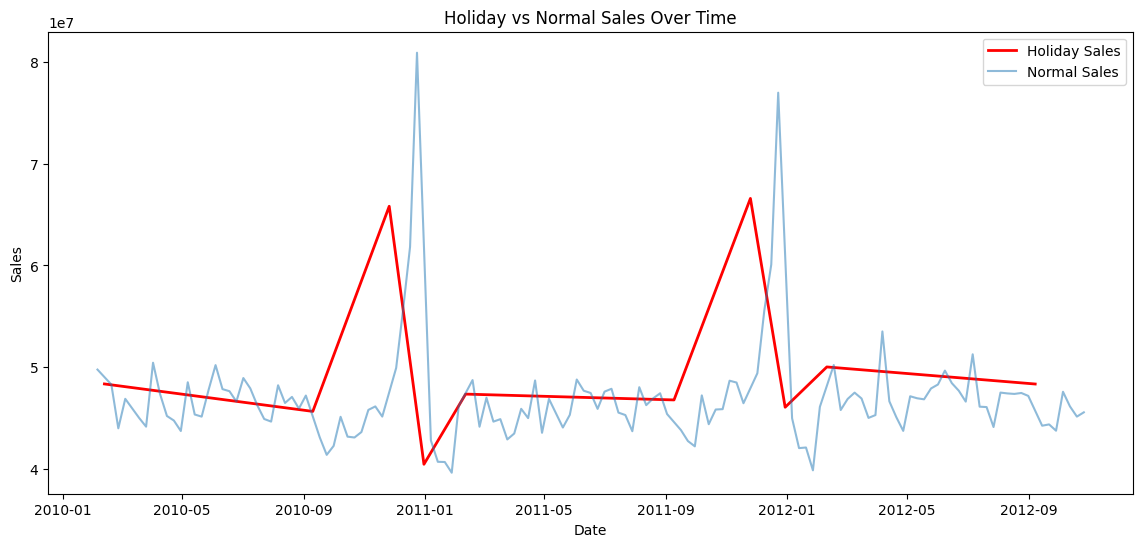

In [19]:
# 9. Holiday impact on sales
holiday_sales = df[df['IsHoliday'] == True].groupby('Date')['Weekly_Sales'].sum()
normal_sales = df[df['IsHoliday'] == False].groupby('Date')['Weekly_Sales'].sum()

plt.figure(figsize=(14,6))
plt.plot(holiday_sales.index, holiday_sales.values, label='Holiday Sales', color='red', linewidth=2)
plt.plot(normal_sales.index, normal_sales.values, label='Normal Sales', alpha=0.5)
plt.title("Holiday vs Normal Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

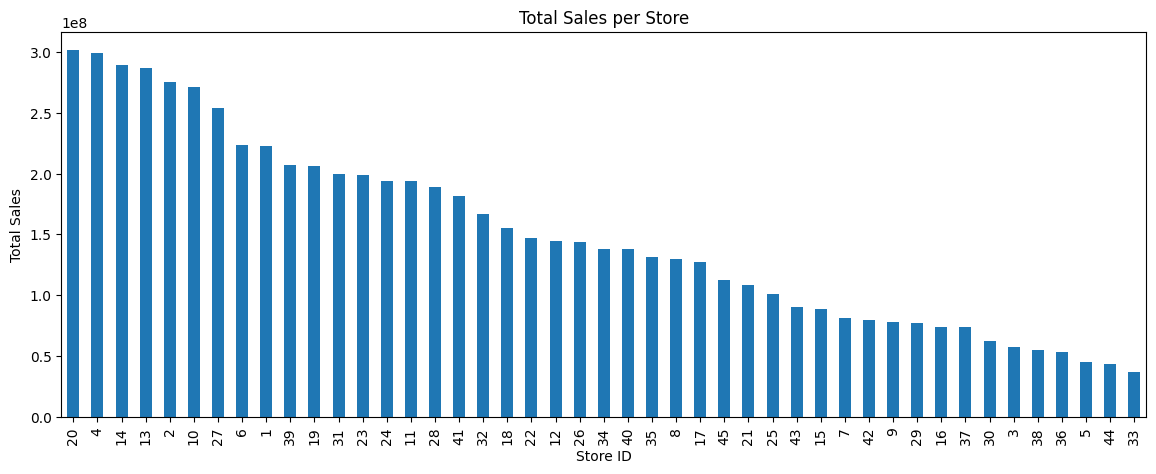

In [20]:
# 10. Store-wise total sales
store_sales = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(14,5))
store_sales.plot(kind='bar')
plt.title("Total Sales per Store")
plt.xlabel("Store ID")
plt.ylabel("Total Sales")
plt.show()

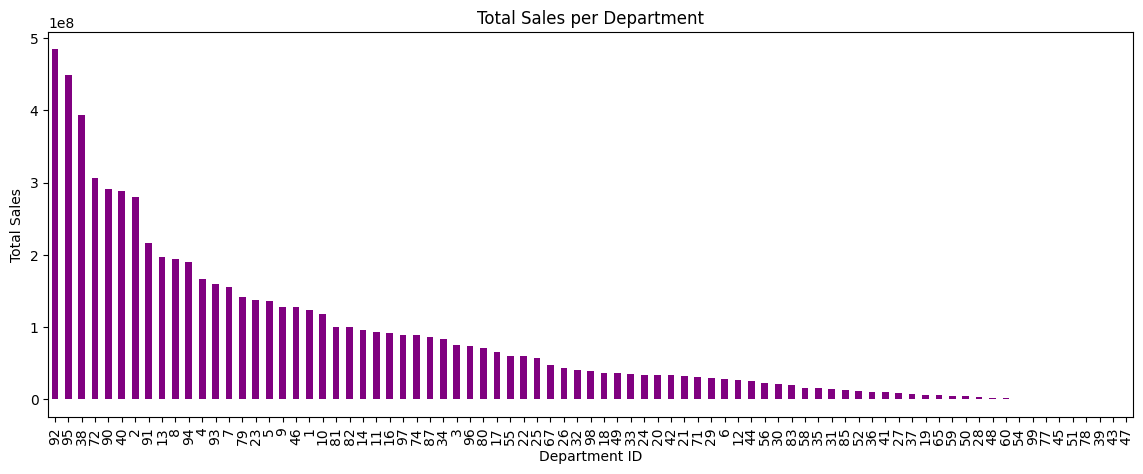

In [21]:
# 11. Department-wise total sales
dept_sales = df.groupby('Dept')['Weekly_Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(14,5))
dept_sales.plot(kind='bar', color='purple')
plt.title("Total Sales per Department")
plt.xlabel("Department ID")
plt.ylabel("Total Sales")
plt.show()


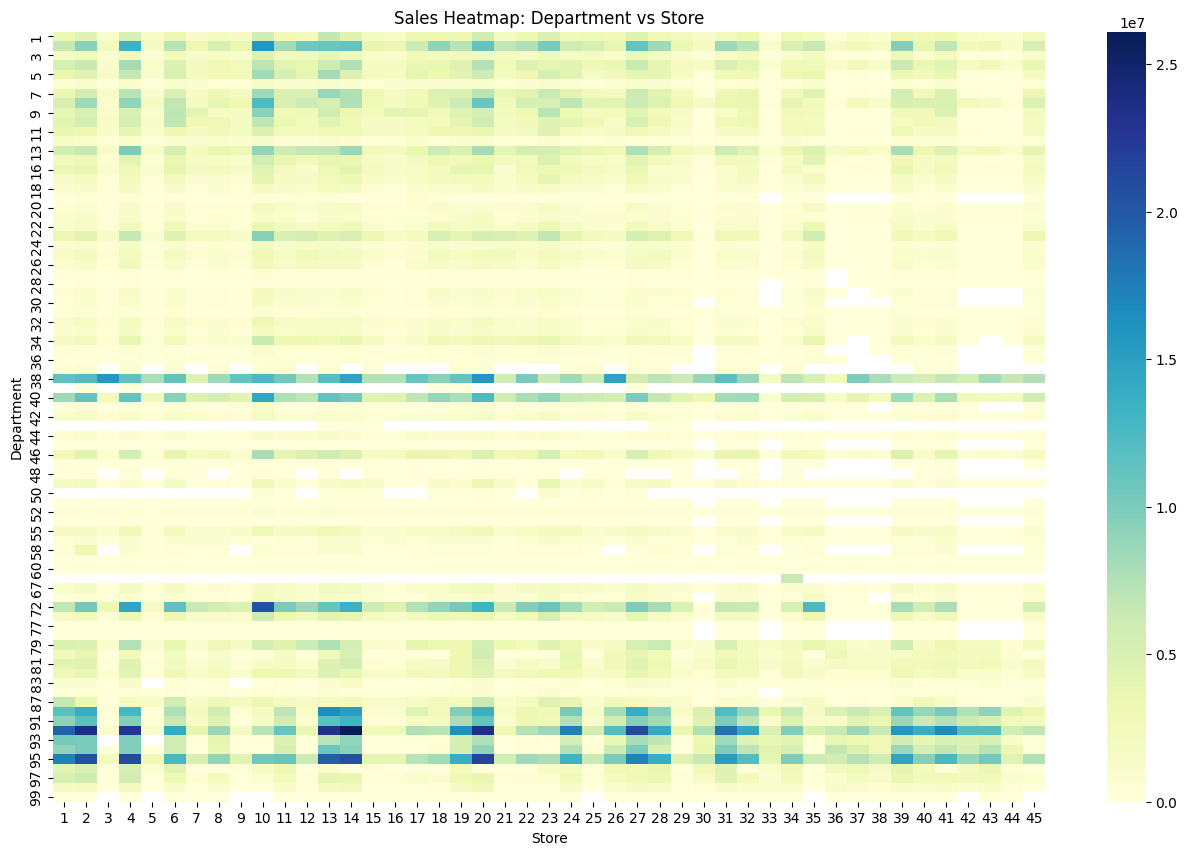

In [22]:
# 12. Heatmap - Store vs Department
pivot_table = df.pivot_table(values='Weekly_Sales', index='Dept', columns='Store', aggfunc='sum')

plt.figure(figsize=(16,10))
sns.heatmap(pivot_table, cmap='YlGnBu')
plt.title("Sales Heatmap: Department vs Store")
plt.xlabel("Store")
plt.ylabel("Department")
plt.show()


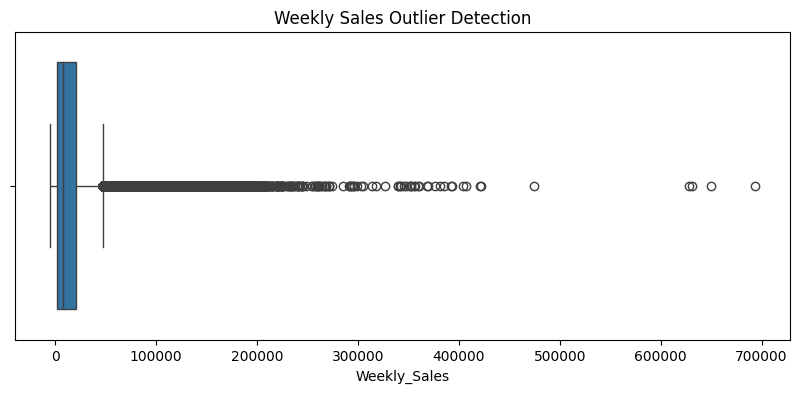

In [23]:
# 13. Boxplot for outliers
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Weekly_Sales'])
plt.title("Weekly Sales Outlier Detection")
plt.show()


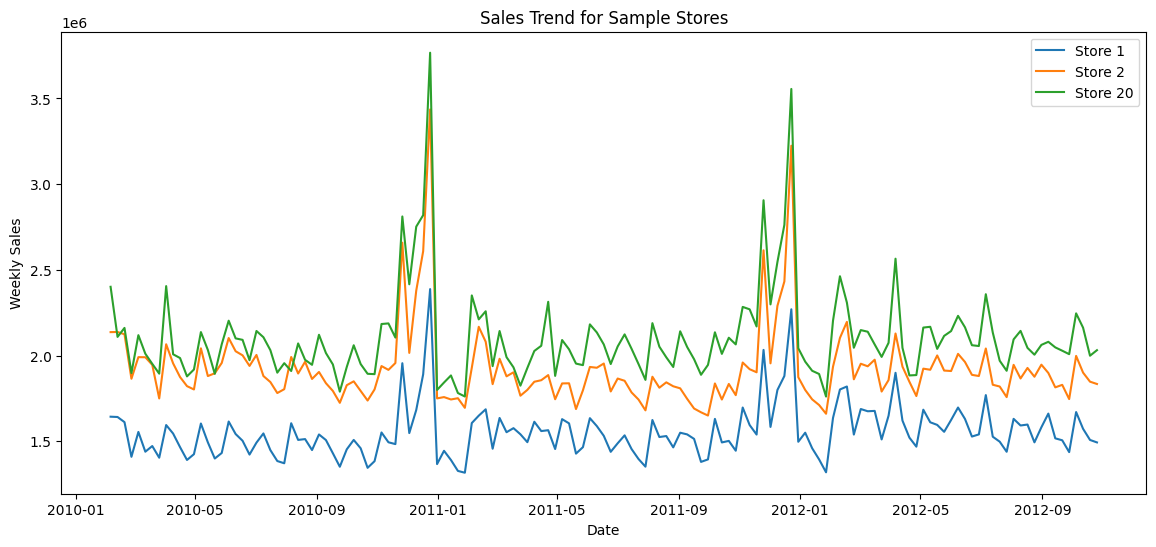

In [24]:
# 14. Sales trend for selected stores
sample_stores = [1, 2, 20]
plt.figure(figsize=(14,6))
for store in sample_stores:
    sales_data = df[df['Store'] == store]
    grouped = sales_data.groupby('Date')['Weekly_Sales'].sum()
    plt.plot(grouped.index, grouped.values, label=f'Store {store}')

plt.title("Sales Trend for Sample Stores")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.show()

In [25]:
# Convert 'Date' to datetime
train['Date'] = pd.to_datetime(train['Date'])
features['Date'] = pd.to_datetime(features['Date'])

# Check for missing values
print(train.isnull().sum())
print(features.isnull().sum())
print(stores.isnull().sum())

# Merge datasets for unified analysis
df = train.merge(features, on=['Store', 'Date'], how='left')
df = df.merge(stores, on='Store', how='left')


Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64
Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64
Store    0
Type     0
Size     0
dtype: int64


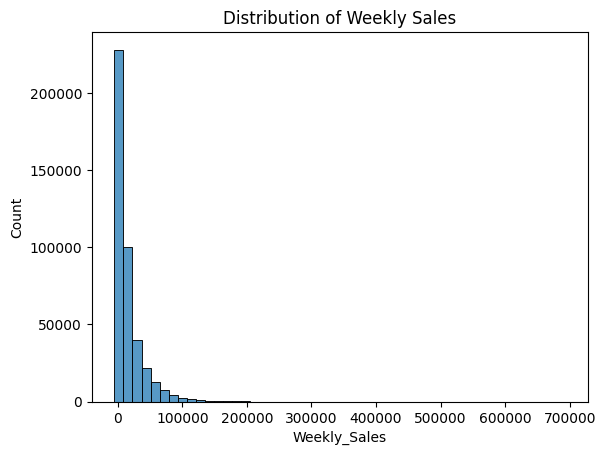

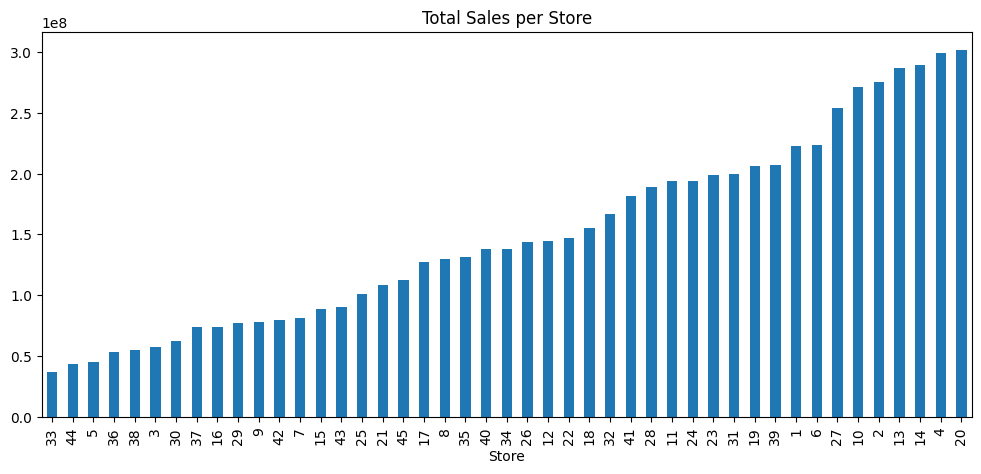

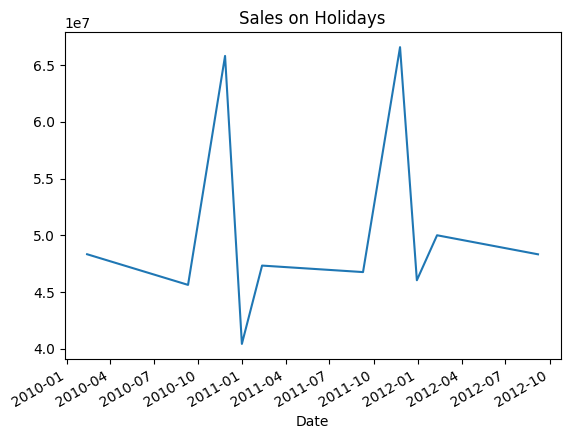

In [29]:
# Sales distribution
sns.histplot(df['Weekly_Sales'], bins=50)
plt.title("Distribution of Weekly Sales")
plt.show()

# Store-wise sales
store_sales = df.groupby('Store')['Weekly_Sales'].sum().sort_values()
store_sales.plot(kind='bar', figsize=(12,5), title='Total Sales per Store')
plt.show()

# Impact of holidays
holiday_sales = df[df['IsHoliday_x'] == True].groupby('Date')['Weekly_Sales'].sum()
holiday_sales.plot(kind='line', title='Sales on Holidays')
plt.show()


In [28]:
print(df.columns.tolist())


['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday_x', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday_y', 'Type', 'Size']


In [30]:
# Merge train with features on ['Store', 'Date']
merged = pd.merge(train_df, features_df, on=['Store', 'Date'], how='left')

# Merge the result with stores on 'Store'
final_df = pd.merge(merged, stores_df, on='Store', how='left')

print("Shape after merging:", final_df.shape)
final_df.head()


NameError: name 'train_df' is not defined